# Week 6 - Exercises

## Exercise 1: Mixing patterns and assortativity

### Part 1: Assortativity Coefficient

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from networkx.readwrite import json_graph

# load the network
with open("week4_css_network.json") as f:
    G_data = json.load(f)

G = json_graph.node_link_graph(G_data)
print(G)

Graph with 18307 nodes and 73938 edges


In [3]:
# extract the giant connected component (GCC)
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes).copy()
print(f"GCC: {GCC.number_of_nodes()} nodes, {GCC.number_of_edges()} edges")

GCC: 17802 nodes, 72800 edges


In [4]:
# get country for each node in GCC
country = nx.get_node_attributes(GCC, "country")

# check how many nodes have a country
has_country = {n for n, c in country.items() if c is not None and c is not np.nan and str(c) != "nan"}
print(f"Nodes with country: {len(has_country)} / {GCC.number_of_nodes()}")

Nodes with country: 14904 / 17802


In [5]:
# count edges by country pair (only where both have country)
from collections import Counter

edge_counts = Counter()
total_edges = 0

for u, v in GCC.edges():
    cu = country.get(u)
    cv = country.get(v)
    if cu is not None and cv is not None and str(cu) != "nan" and str(cv) != "nan":
        edge_counts[(cu, cv)] += 1
        edge_counts[(cv, cu)] += 1  # count both directions for undirected
        total_edges += 1

print(f"Edges with both countries: {total_edges}")
print(f"Unique countries: {len(set(c for pair in edge_counts for c in pair))}")

Edges with both countries: 52462
Unique countries: 118


In [6]:
# get all unique countries
countries = sorted(set(c for pair in edge_counts for c in pair))

# e_ij = fraction of edges connecting type i to type j
# since we double-counted (both directions), divide by 2 * total_edges
# actually we counted each edge twice in edge_counts, so the total sum of edge_counts = 2 * total_edges
total_2 = 2 * total_edges  # sum of all edge_counts values

# e_ii = fraction of edges where both endpoints are same country
e_ii_sum = sum(edge_counts[(c, c)] for c in countries) / total_2

# a_i = fraction of edge endpoints that are country i
# for undirected: a_i = b_i = sum_j(e_ij)
a = {}
for c in countries:
    a[c] = sum(edge_counts[(c, c2)] for c2 in countries) / total_2

a_sq_sum = sum(a[c] ** 2 for c in countries)

# assortativity
r = (e_ii_sum - a_sq_sum) / (1 - a_sq_sum)
print(f"Assortativity (country): {r:.4f}")

Assortativity (country): 0.3766


### Part 2: Configuration model

In [8]:
def compute_country_assortativity(G, country_attr="country"):
    """Compute assortativity coefficient by country attribute."""
    country = nx.get_node_attributes(G, country_attr)
    
    edge_counts = Counter()
    total_edges = 0
    
    for u, v in G.edges():
        cu = country.get(u)
        cv = country.get(v)
        if cu is not None and cv is not None and str(cu) != "nan" and str(cv) != "nan":
            edge_counts[(cu, cv)] += 1
            edge_counts[(cv, cu)] += 1
            total_edges += 1
    
    if total_edges == 0:
        return 0
    
    countries = sorted(set(c for pair in edge_counts for c in pair))
    total_2 = 2 * total_edges
    
    e_ii_sum = sum(edge_counts[(c, c)] for c in countries) / total_2
    a = {c: sum(edge_counts[(c, c2)] for c2 in countries) / total_2 for c in countries}
    a_sq_sum = sum(v ** 2 for v in a.values())
    
    return (e_ii_sum - a_sq_sum) / (1 - a_sq_sum)

# verify it matches
print(compute_country_assortativity(GCC))

0.3765799903340637


In [9]:
import random

def double_edge_swap(G, n_swaps=None):
    """Create a randomized copy using double edge swap algorithm."""
    R = G.copy()
    edges = list(R.edges())
    E = len(edges)
    
    if n_swaps is None:
        n_swaps = E * 10
    
    swaps_done = 0
    attempts = 0
    max_attempts = n_swaps * 10  # safety limit
    
    while swaps_done < n_swaps and attempts < max_attempts:
        attempts += 1
        
        # b. pick two random edges
        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v = edges[idx1]
        x, y = edges[idx2]
        
        # c. flip e1 50% of the time
        if random.random() < 0.5:
            u, v = v, u
        
        # check u != y and v != x
        if u == y or v == x:
            continue
        
        # also avoid self-loops
        if u == x or v == y:
            continue
        
        # d. check new edges don't already exist
        if R.has_edge(u, y) or R.has_edge(x, v):
            continue
        
        # e. perform the swap
        R.remove_edge(edges[idx1][0], edges[idx1][1])
        R.remove_edge(edges[idx2][0], edges[idx2][1])
        R.add_edge(u, y)
        R.add_edge(x, v)
        
        # update edge list
        edges[idx1] = (u, y)
        edges[idx2] = (x, v)
        
        swaps_done += 1
    
    print(f"Swaps completed: {swaps_done}/{n_swaps} (attempts: {attempts})")
    return R

# test it
R_test = double_edge_swap(GCC)

Swaps completed: 728000/728000 (attempts: 732799)


In [10]:
# check that degree sequence is identical
orig_degrees = sorted(dict(GCC.degree()).values())
rand_degrees = sorted(dict(R_test.degree()).values())

print(f"Degree sequences match: {orig_degrees == rand_degrees}")

Degree sequences match: True


### Part 3: Analyzing Assortativity in Random Networks

In [11]:
from joblib import Parallel, delayed

def swap_and_compute(G, i):
    R = double_edge_swap(G)
    r = compute_country_assortativity(R)
    return r

# this will take a while — 100 networks × ~728k swaps each
random_assortativities = Parallel(n_jobs=5, verbose=5)(
    delayed(swap_and_compute)(GCC, i) for i in range(100)
)

print(f"Done! Mean: {np.mean(random_assortativities):.4f}, Std: {np.std(random_assortativities):.4f}")

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Swaps completed: 728000/728000 (attempts: 732948)
Swaps completed: 728000/728000 (attempts: 732957)
Swaps completed: 728000/728000 (attempts: 732928)
Swaps completed: 728000/728000 (attempts: 732960)
Swaps completed: 728000/728000 (attempts: 732945)
Swaps completed: 728000/728000 (attempts: 732996)
Swaps completed: 728000/728000 (attempts: 732946)
Swaps completed: 728000/728000 (attempts: 733048)
Swaps completed: 728000/728000 (attempts: 733107)
Swaps completed: 728000/728000 (attempts: 732925)


[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    8.6s


Swaps completed: 728000/728000 (attempts: 732937)
Swaps completed: 728000/728000 (attempts: 732912)
Swaps completed: 728000/728000 (attempts: 732934)
Swaps completed: 728000/728000 (attempts: 732820)
Swaps completed: 728000/728000 (attempts: 732959)
Swaps completed: 728000/728000 (attempts: 732927)
Swaps completed: 728000/728000 (attempts: 732916)
Swaps completed: 728000/728000 (attempts: 732947)
Swaps completed: 728000/728000 (attempts: 733058)
Swaps completed: 728000/728000 (attempts: 732895)
Swaps completed: 728000/728000 (attempts: 732896)
Swaps completed: 728000/728000 (attempts: 732880)
Swaps completed: 728000/728000 (attempts: 732937)
Swaps completed: 728000/728000 (attempts: 733025)
Swaps completed: 728000/728000 (attempts: 732901)
Swaps completed: 728000/728000 (attempts: 733066)
Swaps completed: 728000/728000 (attempts: 732843)
Swaps completed: 728000/728000 (attempts: 733025)
Swaps completed: 728000/728000 (attempts: 732935)
Swaps completed: 728000/728000 (attempts: 732960)


[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:   54.9s


Swaps completed: 728000/728000 (attempts: 732840)
Swaps completed: 728000/728000 (attempts: 732817)
Swaps completed: 728000/728000 (attempts: 732929)
Swaps completed: 728000/728000 (attempts: 732950)
Swaps completed: 728000/728000 (attempts: 732882)
Swaps completed: 728000/728000 (attempts: 732955)
Swaps completed: 728000/728000 (attempts: 733033)
Swaps completed: 728000/728000 (attempts: 732902)
Swaps completed: 728000/728000 (attempts: 732914)
Swaps completed: 728000/728000 (attempts: 733135)
Swaps completed: 728000/728000 (attempts: 732957)
Swaps completed: 728000/728000 (attempts: 732884)
Swaps completed: 728000/728000 (attempts: 733022)
Swaps completed: 728000/728000 (attempts: 732930)
Swaps completed: 728000/728000 (attempts: 732826)
Swaps completed: 728000/728000 (attempts: 732882)
Swaps completed: 728000/728000 (attempts: 732869)
Swaps completed: 728000/728000 (attempts: 732962)
Swaps completed: 728000/728000 (attempts: 732991)
Swaps completed: 728000/728000 (attempts: 732934)


[Parallel(n_jobs=5)]: Done 100 out of 100 | elapsed:  1.4min finished


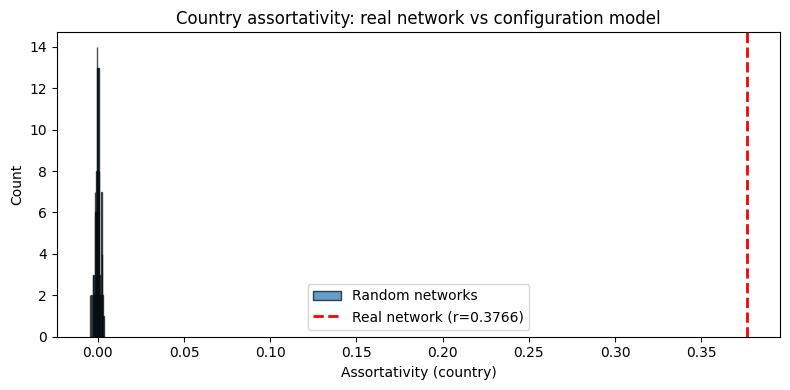

In [12]:
real_r = compute_country_assortativity(GCC)

plt.figure(figsize=(8, 4))
plt.hist(random_assortativities, bins=20, edgecolor="black", alpha=0.7, label="Random networks")
plt.axvline(real_r, color="red", linewidth=2, linestyle="--", label=f"Real network (r={real_r:.4f})")
plt.xlabel("Assortativity (country)")
plt.ylabel("Count")
plt.title("Country assortativity: real network vs configuration model")
plt.legend()
plt.tight_layout()
plt.show()

### Part 4: Degree assortativity

In [17]:
def compute_degree_assortativity(G):
    """Compute degree assortativity using Pearson correlation of degrees at edge endpoints."""
    edges = list(G.edges())
    deg = dict(G.degree())
    
    x = np.array([deg[u] for u, v in edges])
    y = np.array([deg[v] for u, v in edges])
    
    # symmetric — count both directions
    x_all = np.concatenate([x, y])
    y_all = np.concatenate([y, x])
    
    mean_x = np.mean(x_all)
    mean_y = np.mean(y_all)
    
    numerator = np.mean(x_all * y_all) - mean_x * mean_y
    denominator = np.sqrt((np.mean(x_all**2) - mean_x**2) * (np.mean(y_all**2) - mean_y**2))
    
    return numerator / denominator

r_degree = compute_degree_assortativity(GCC)
print(f"Degree assortativity: {r_degree:.4f}")

Degree assortativity: -0.0820


In [19]:
def double_edge_swap(G, n_swaps=None):
    """Create a randomized copy using double edge swap algorithm."""
    R = G.copy()
    edges = list(R.edges())
    E = len(edges)
    
    if n_swaps is None:
        n_swaps = E * 10
    
    swaps_done = 0
    attempts = 0
    max_attempts = n_swaps * 10
    
    while swaps_done < n_swaps and attempts < max_attempts:
        attempts += 1
        
        idx1, idx2 = random.sample(range(len(edges)), 2)
        e1 = edges[idx1]
        e2 = edges[idx2]
        
        u, v = e1
        x, y = e2
        
        if random.random() < 0.5:
            u, v = v, u
        
        if u == y or v == x or u == x or v == y:
            continue
        
        if R.has_edge(u, y) or R.has_edge(x, v):
            continue
        
        # verify edges still exist before removing
        if not R.has_edge(*e1) or not R.has_edge(*e2):
            # edge list out of sync — refresh it
            edges = list(R.edges())
            continue
        
        R.remove_edge(*e1)
        R.remove_edge(*e2)
        R.add_edge(u, y)
        R.add_edge(x, v)
        
        edges[idx1] = (u, y)
        edges[idx2] = (x, v)
        
        swaps_done += 1
    
    return R

def swap_and_compute_degree(G, i):
    R = double_edge_swap(G)
    return compute_degree_assortativity(R)

random_degree_assort = Parallel(n_jobs=5, verbose=5)(
    delayed(swap_and_compute_degree)(GCC, i) for i in range(100)
)

print(f"Done! Mean: {np.mean(random_degree_assort):.4f}, Std: {np.std(random_degree_assort):.4f}")

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    8.6s
[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:   54.7s


Done! Mean: -0.0098, Std: 0.0029


[Parallel(n_jobs=5)]: Done 100 out of 100 | elapsed:  1.4min finished


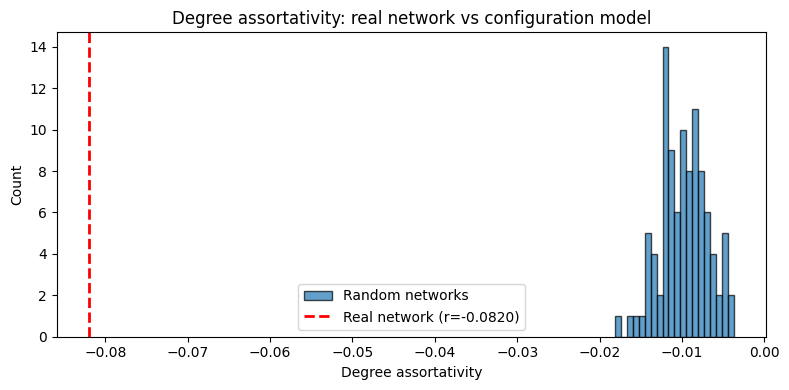

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(random_degree_assort, bins=20, edgecolor="black", alpha=0.7, label="Random networks")
plt.axvline(r_degree, color="red", linewidth=2, linestyle="--", label=f"Real network (r={r_degree:.4f})")
plt.xlabel("Degree assortativity")
plt.ylabel("Count")
plt.title("Degree assortativity: real network vs configuration model")
plt.legend()
plt.tight_layout()
plt.show()

**7. Degree assortativity — expected?**

the negative degree assortativity (-0.082) makes sense for a co-authorship network. 
prolific researchers (high degree) tend to collaborate with many different people, 
including less-connected researchers like phd students and postdocs. this creates a 
hub-and-spoke pattern where high-degree nodes connect to many low-degree nodes rather 
than forming an exclusive club of highly connected scientists.

**8. Edge flipping — why?**

when we build the edge list from the graph, edges are often stored in a sorted order 
(e.g. alphabetically by node id). if we always pick e1 = (u,v) without flipping, the 
new edges e1' = (u, y) and e2' = (x, v) would inherit this sorting bias — u would 
always be the "earlier" node. flipping e1 50% of the time removes this bias and ensures 
the rewiring is truly random.

**9. Distribution of random assortativity**

the random networks show degree assortativity tightly clustered around -0.01, with a 
small standard deviation (~0.003). the slight negative value is expected because the 
configuration model preserves the degree sequence, which is heavy-tailed — high-degree 
nodes simply have more edges, so they're statistically more likely to connect to 
low-degree nodes even by chance. the tight distribution reflects the law of large 
numbers: with ~73k edges, each randomized network converges to a similar value.

## Exercise 2: Central nodes

## Exercise 3: Zachary’s karate club

## Exercise 4: Community detection on the network of CSS